In [1]:
from processing.auto_cluster_dl import auto_cluster_dl_hdbscan
from processing.clahe import chalhe_images
from processing.make_crops import make_crops
from processing.megadetector_step import megadetector_classify
from processing.divide import divide_images
from processing.remove_footer import remove_footer
import os
import shutil
import numpy as np

# --- CONFIGURACIÓN ---
PATH = os.getcwd()
SRC_IMAGES = os.path.join(PATH, 'dataset_ecuador')
IMAGES = os.path.join(PATH, 'images')
# Carpetas intermedias
SORTED_DIR = os.path.join(PATH, 'images_sorted')
CROPS_RAW_DIR = os.path.join(PATH, 'crops')
CROPS_CLAHE_DIR = os.path.join(PATH, 'crops_clahe_processed')
CLUSTERS_OUTPUT = os.path.join(PATH, 'Clusters')       # Salida final
# Definimos rutas claras

ANIMALS_FOLDER = 'Animales'
EMPTY_FOLDER = 'Vacias'

path_animales_img = os.path.join(SORTED_DIR, ANIMALS_FOLDER)

/home/ariel/Desktop/iwildcam_preprocessing_pipeline/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Pipeline

In [2]:
# --- PIPELINE ---

print("=== INICIANDO PIPELINE (MegaDetector -> Crop -> CLAHE -> ResNet50) ===")

=== INICIANDO PIPELINE (MegaDetector -> Crop -> CLAHE -> ResNet50) ===


# Box Generations

In [3]:
# 1. MEGADETECTOR
print("\n--- Paso 1: MegaDetector ---")
if os.path.exists('resultados_megadetector.json'):
    print("JSON detectado. Saltando.")
else:
    megadetector_classify(
        input_folder=SRC_IMAGES,
        output_file='resultados_megadetector.json',
        model_version='MDV5A',
        conf_threshold=0.2,
        recursive=True
    )


--- Paso 1: MegaDetector ---
--- Iniciando MegaDetector Pipeline ---
Carpeta de imágenes: /home/ariel/Desktop/iwildcam_preprocessing_pipeline/dataset_ecuador
Buscando imágenes...
Se encontraron 9241 imágenes.
Redimensionando imágenes a máximo 1600 px en: /home/ariel/Desktop/iwildcam_preprocessing_pipeline/dataset_ecuador/_resized_for_md
Cargando modelo y ejecutando detección...
Model v5a.0.1 already exists and is valid at /tmp/megadetector_models/md_v5a.0.1.pt
PyTorch reports 2 available CUDA devices
GPU available: False
PyTorch reports 2 available CUDA devices
GPU available: False


/home/ariel/Desktop/iwildcam_preprocessing_pipeline/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Loading PT detector with compatibility mode classic
Loaded image size 1280 from model metadata
Using model stride: 64
PTDetector using device cpu


Fusing layers... 
Fusing layers... 
Model summary: 733 layers, 140054656 parameters, 0 gradients, 208.8 GFLOPs
Model summary: 733 layers, 140054656 parameters, 0 gradients, 208.8 GFLOPs


Loaded model in 0.74 seconds
Batch size of 32 requested, but no GPU is available, using batch size 1


...

Processing image /home/ariel/Desktop/iwildcam_preprocessing_pipeline/dataset_ecuador/_resized_for_md/ecuador1_ic1619_20181202_095139_img_1413.jpg


100%|█████████▉| 3340/3341 [22:28<00:00,  2.43it/s]

Processing image /home/ariel/Desktop/iwildcam_preprocessing_pipeline/dataset_ecuador/_resized_for_md/ecuador1_ic1611_20150101_000003_img_3061.jpg


100%|██████████| 3341/3341 [22:28<00:00,  2.48it/s]

Guardando resultados en /home/ariel/Desktop/iwildcam_preprocessing_pipeline/resultados_megadetector.json...
Output file saved at /home/ariel/Desktop/iwildcam_preprocessing_pipeline/resultados_megadetector.json
--- ¡Proceso Terminado! ---


In [4]:
# 2. DIVIDE
print("\n--- Paso 2: Dividir ---")
divide_images(
    json_file='resultados_megadetector.json',
    source_folder=SRC_IMAGES,
    dest_root=SORTED_DIR,
    animals_folder_name=ANIMALS_FOLDER,
    empty_folder_name=EMPTY_FOLDER,
    conf_threshold=0.4,
    accepted_categories=['1']
)


--- Paso 2: Dividir ---
Cargando resultados_megadetector.json...
--- Comenzando la clasificación ---
Movido: _resized_for_md/ecuador1_cam1612_20150101_010031_img_1113.jpg → Vacias (Conf: 0.00)
Movido: _resized_for_md/ecuador1_cam1612_20150101_010409_img_1114.jpg → Vacias (Conf: 0.00)
Movido: _resized_for_md/ecuador1_cam1612_20150101_013820_img_1217.jpg → Vacias (Conf: 0.00)
Movido: _resized_for_md/ecuador1_cam1612_20150101_225927_img_1220.jpg → Vacias (Conf: 0.00)
Movido: _resized_for_md/ecuador1_cam1612_20150103_025339_img_1231.jpg → Vacias (Conf: 0.00)
Movido: _resized_for_md/ecuador1_cam1612_20150103_054019_img_1232.jpg → Vacias (Conf: 0.00)
Movido: _resized_for_md/ecuador1_cam1612_20150103_062943_img_1233.jpg → Vacias (Conf: 0.00)
Movido: _resized_for_md/ecuador1_cam1612_20150104_010724_img_1239.jpg → Vacias (Conf: 0.00)
Movido: _resized_for_md/ecuador1_cam1612_20150104_011418_img_1240.jpg → Vacias (Conf: 0.00)
Movido: _resized_for_md/ecuador1_cam1612_20150104_013417_img_1241.jpg 

# Crops Generations

In [5]:
# 3. MAKE CROPS
print("\n--- Paso 3: Recortes (Crops) ---")

make_crops(
    json_file='resultados_megadetector.json',
    input_folder=path_animales_img,
    output_folder=CROPS_RAW_DIR,
    conf_threshold=0.4,
    accepted_categories=['1']
)

shutil.rmtree(SORTED_DIR)


--- Paso 3: Recortes (Crops) ---
Cargando resultados_megadetector.json...
--- Fase 1: Analizando dimensiones para encontrar la mediana ---


Analizando tamaños: 100%|██████████| 3341/3341 [00:00<00:00, 170952.77it/s]



>>> TAMAÑO MEDIO CALCULADO: 492x457 px

--- Fase 2: Iniciando Recorte Inteligente ---


Generando crops: 100%|██████████| 3341/3341 [00:00<00:00, 4571.64it/s] 



--- Resumen Final ---
Mediana usada: 492x457 px
Recortes generados: 113
Errores: 0


# Filter and preprocessing image section

In [6]:
# 4. CLAHE
print("\n--- Paso 4: CLAHE ---")

chalhe_images(
    input_dir=CROPS_RAW_DIR,
    output_dir=CROPS_CLAHE_DIR
)

shutil.rmtree(CROPS_RAW_DIR)


--- Paso 4: CLAHE ---
Procesando 113 imágenes con CLAHE + Normalize + Pad + Resize...


 12%|█▏        | 13/113 [00:00<00:00, 128.26it/s]

pad → cuadrada
resize → tamaño uniforme para ResNet
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ResNet
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ResNet
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ResNet
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ResNet
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ResNet
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ResNet
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ResNet
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ResNet
normalizar color (Gray World

100%|██████████| 113/113 [00:00<00:00, 326.58it/s]

pad → cuadrada
resize → tamaño uniforme para ResNet
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ResNet
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ResNet
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ResNet
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ResNet
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ResNet
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ResNet
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ResNet
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ResNet
normalizar color (Gray World

# Image reduction and features extraction

In [3]:
# 5. AUTO CLUSTER (RESNET)
print("\n--- Paso 5: Clustering con ViT + UMAP ---")
# CAMBIO: Usamos la función que integra ResNet
clusterer, embedding = auto_cluster_dl_hdbscan(
    input_dir="Ecuador/crops_clahe_processed",    # Usamos los crops mejorados
    output_dir="Ecuador/Clusters",
    min_cluster_size=15
)

print(f"\n¡LISTO! Revisa la carpeta: {CLUSTERS_OUTPUT}")


--- Paso 5: Clustering con ViT + UMAP ---
--- Paso 1: Extracción de Features con ViT ---
--- Configurando DeepFaune ViT ---
Usando dispositivo: cuda
Cargando pesos desde: /home/ariel/Desktop/iwildcam_preprocessing_pipeline/models/deepfaune-vit_large_patch14_dinov2.lvd142m.v4.pt
Buscando imágenes...
Total de imágenes a procesar: 113
Iniciando extracción de features...


100%|██████████| 4/4 [00:00<00:00,  6.43it/s]
/home/ariel/Desktop/iwildcam_preprocessing_pipeline/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Extracción completa.
Dimensiones finales: (113, 1024)
Features guardados en: temp_features.npy
Lista de archivos guardada en: temp_filenames.json
Features cargados: (113, 1024)
--- Paso 2: Reducción de Dimensionalidad (UMAP) ---
Dimensiones reducidas con UMAP: (113, 15)
--- Paso 3: Clustering con HDBSCAN (min_cluster_size=15) ---

>>> RESULTADO: Se encontraron 4 clusters y 10 imágenes de Ruido (-1).
--- Paso 4: Organizando archivos ---


Moviendo archivos: 100%|██████████| 113/113 [00:00<00:00, 11502.68it/s]


--- RESUMEN FINAL ---
Cluster_00: 27 imágenes
Cluster_01: 32 imágenes
Cluster_02: 20 imágenes
Cluster_03: 24 imágenes
Cluster_Ruido_Outliers: 10 imágenes

¡LISTO! Revisa la carpeta: /home/ariel/Desktop/iwildcam_preprocessing_pipeline/Clusters


# Metrics Report

# Unsupervised metrics

*   **Silhouette Score:** Measures how well each point is assigned to its correct cluster (good separation).
*   **Cohesion (Heuristic Cohesion):** Measures how tightly packed the points within a cluster are.
*   **Confidence (HDBSCAN):** Evaluates how confident HDBSCAN is that a point belongs to a cluster.
*   **Persistence (HDBSCAN):** Measures how stable a cluster is over time.

In [4]:
from sklearn.metrics import silhouette_score

labels = clusterer.fit_predict(embedding)

# --- 3.1 MÉTRICA: SILHOUETTE (ignorando ruido) ---
mask = labels != -1

if np.sum(mask) > 1 and len(set(labels[mask])) > 1:
    silhouette = silhouette_score(
        embedding[mask],
        labels[mask],
        metric='euclidean'  # coherente con HDBSCAN en UMAP
    )
    print(f"Silhouette Score (sin ruido): {silhouette:.4f}")
else:
    print("No se puede calcular Silhouette (muy pocos clusters o puntos).")

Silhouette Score (sin ruido): 0.8353


In [ ]:
from sklearn.metrics import silhouette_samples

sil_samples = silhouette_samples(embedding, labels)

cluster_silhouette = {}
for c in set(labels):
    if c == -1: continue
    cluster_silhouette[c] = (sil_samples[labels == c].mean())

In [ ]:
from scipy.spatial.distance import pdist

def cohesion(cluster_points):
    return pdist(cluster_points).mean()

cluster_cohesion = {}

for c in set(labels):
    if c == -1: continue
    points = embedding[labels == c]
    cluster_cohesion[c] = cohesion(points)

In [7]:
import numpy as np

vals = np.array(list(cluster_cohesion.values()))
norm = (vals - vals.min()) / (vals.max() - vals.min())

print(dict(zip(cluster_cohesion.keys(), norm)))

{np.int64(0): np.float64(0.7177132811292533), np.int64(1): np.float64(1.0), np.int64(2): np.float64(0.0), np.int64(3): np.float64(0.08469749161163181)}


In [ ]:
cluster_confidence = {}

for c in set(labels):
    if c == -1: continue
    cluster_confidence[c] = clusterer.probabilities_[labels == c].mean()

In [9]:
clusterer.cluster_persistence_

array([0.70327995, 0.80724207, 0.06601535, 0.14384475])

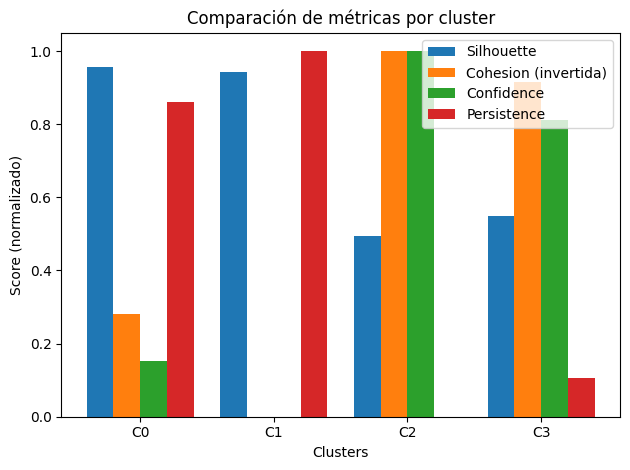

In [11]:
import numpy as np
import matplotlib.pyplot as plt

clusters = sorted(cluster_silhouette.keys())

# --- 1. Extraer métricas en orden consistente ---
sil_vals = np.array([cluster_silhouette[c] for c in clusters])
coh_vals = np.array([cluster_cohesion[c] for c in clusters])
conf_vals = np.array([cluster_confidence[c] for c in clusters])

# --- 2. Normalizar cohesión (ya la tienes, pero lo hacemos ordenado) ---
coh_norm = (coh_vals - coh_vals.min()) / (coh_vals.max() - coh_vals.min())

# Invertir cohesión para que "más alto = mejor"
coh_norm_inv = 1 - coh_norm

# --- 3. Normalizar confidence (opcional, ya suele estar en [0,1]) ---
conf_norm = (conf_vals - conf_vals.min()) / (conf_vals.max() - conf_vals.min())

# --- 4. Persistencia (ojo: HDBSCAN ya la da por cluster en orden interno) ---
# Asegúrate que el orden coincide con tus labels
persistence_vals = clusterer.cluster_persistence_
persistence_norm = (persistence_vals - persistence_vals.min()) / (
    persistence_vals.max() - persistence_vals.min()
)

# --- 5. Preparar gráfica ---
x = np.arange(len(clusters))
width = 0.2

plt.figure()

plt.bar(x - 1.5*width, sil_vals, width, label='Silhouette')
plt.bar(x - 0.5*width, coh_norm_inv, width, label='Cohesion (invertida)')
plt.bar(x + 0.5*width, conf_norm, width, label='Confidence')
plt.bar(x + 1.5*width, persistence_norm[:len(clusters)], width, label='Persistence')

# --- 6. Labels ---
plt.xticks(x, [f"C{c}" for c in clusters])
plt.xlabel("Clusters")
plt.ylabel("Score (normalizado)")
plt.title("Comparación de métricas por cluster")
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
print("\n" + "="*60)
print("RESUMEN DE MÉTRICAS POR CLUSTER")
print("="*60)
print(f"{'Cluster':<10} {'Silh':<10} {'Coh(inv)':<10} {'Conf':<10} {'Persist':<10}")
print("-"*60)

for i, c in enumerate(clusters):
    print(f"C{c:<9} {sil_vals[i]:<10.3f} {coh_norm_inv[i]:<10.3f} {conf_norm[i]:<10.3f} {persistence_norm[i]:<10.3f}")



RESUMEN DE MÉTRICAS POR CLUSTER
Cluster    Silh       Coh(inv)   Conf       Persist   
------------------------------------------------------------
C0         0.956      0.282      0.153      0.860     
C1         0.944      0.000      0.000      1.000     
C2         0.496      1.000      1.000      0.000     
C3         0.548      0.915      0.811      0.105     


# Supervised metrics

- Homogeneidad (Homogeneity)
Mide qué tan “puros” son los clusters: cada cluster debería contener elementos de una sola clase.  
Valor alto → cada cluster tiene una sola categoría dominante.

- Completitud (Completeness)
Mide qué tan bien todos los elementos de una misma clase están agrupados en un solo cluster.  
Valor alto → una clase no está fragmentada en múltiples clusters.

- V-Measure
Media armónica entre homogeneidad y completitud.  
Balancea ambos criterios: pureza interna del cluster y agrupación completa de cada clase.

- Adjusted Rand Index (ARI)
Mide la similitud entre clustering y etiquetas reales considerando todas las parejas de puntos.  
Está ajustado por azar (0 = aleatorio, 1 = perfecto).
- Pureza (Purity)
Mide qué proporción del cluster pertenece a la clase mayoritaria.  
Se calcula como: (elementos de la clase dominante / total del cluster).  
Valor alto → cluster dominado por una sola clase.

In [13]:
import os
import re
import json
from collections import defaultdict, Counter
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score, adjusted_rand_score

# --- CONFIGURACIÓN ---
CLUSTERS_DIR = "/home/ariel/Desktop/iwildcam_preprocessing_pipeline/Ecuador/Clusters"
JSON_PATH = "island_conservation_camera_traps_1.02.json"
# ---------------------

In [14]:
print("1. Buscando recortes en las carpetas de clusters...")
crop_files = []

if not os.path.exists(CLUSTERS_DIR):
    print(f"Error: No se encontró el directorio {CLUSTERS_DIR}")
else:
    for root, dirs, files in os.walk(CLUSTERS_DIR):
        cluster_name = os.path.basename(root)
        if cluster_name == "Clusters": continue
        
        for file in files:
            if file.lower().endswith('.jpg'):
                match = re.search(r'(.*)_crop(\d+)\.jpg$', file, re.IGNORECASE)
                if match:
                    basename = match.group(1)
                    crop_idx = int(match.group(2))
                    crop_files.append({
                        'cluster': cluster_name,
                        'basename': basename,
                        'crop_idx': crop_idx,
                        'filename': file
                    })

    print(f"Se encontraron {len(crop_files)} recortes agrupados en carpetas.")

    unique_basenames = {item['basename'] for item in crop_files}

    print(f"2. Cargando JSON de anotaciones desde {JSON_PATH}...")
    with open(JSON_PATH, 'r') as f:
        data = json.load(f)

    print("3. Procesando listado de anotaciones...")
    img_id_to_annotations = defaultdict(list)
    for ann in data.get("annotations", []):
        img_id_to_annotations[ann["image_id"]].append(ann["category_id"])

    print("4. Emparejando archivos físicos con IDs del JSON...")
    basename_to_image_id = {}
    for img_id in img_id_to_annotations.keys():
        for b_name in unique_basenames:
            if img_id.endswith(b_name) or img_id == b_name:
                basename_to_image_id[b_name] = img_id
                
    print("5. Preparando listas para métricas...")
    y_true_all = []
    y_pred_all = []
    y_true_no_noise = []
    y_pred_no_noise = []
    cluster_contents = defaultdict(list)

    for crop in crop_files:
        basename = crop['basename']
        cluster = crop['cluster']
        crop_idx = crop['crop_idx']
        
        img_id = basename_to_image_id.get(basename)
        if img_id is None: continue
            
        categories = img_id_to_annotations[img_id]
        if crop_idx < len(categories):
            cat_id = categories[crop_idx]
            y_true_all.append(cat_id)
            y_pred_all.append(cluster)
            
            is_noise_cluster = str(cluster) in ["-1", "Cluster_-1", "Cluster_Ruido_Outliers"]
            if not is_noise_cluster:
                y_true_no_noise.append(cat_id)
                y_pred_no_noise.append(cluster)
            
            cluster_contents[cluster].append(cat_id)


1. Buscando recortes en las carpetas de clusters...
Se encontraron 113 recortes agrupados en carpetas.
2. Cargando JSON de anotaciones desde island_conservation_camera_traps_1.02.json...
3. Procesando listado de anotaciones...
4. Emparejando archivos físicos con IDs del JSON...
5. Preparando listas para métricas...


In [15]:
if not y_true_all:
    print("Error: No se logró completar el emparejamiento con el JSON.")
else:
    homogeneity_all = homogeneity_score(y_true_all, y_pred_all)
    completeness_all = completeness_score(y_true_all, y_pred_all)
    vmeasure_all = v_measure_score(y_true_all, y_pred_all)
    ari_all = adjusted_rand_score(y_true_all, y_pred_all)
    
    print("\n" + "=" * 50)
    print("RESULTADOS GLOBALES SKLEARN (CON RUIDO)")
    print("=" * 50)
    print(f"Total imágenes analizadas exitosamente: {len(y_true_all)}")
    print(f"Homogeneidad Global: {homogeneity_all:.4f}")
    print(f"Completitud Global : {completeness_all:.4f}")
    print(f"V-Measure          : {vmeasure_all:.4f}")
    print(f"Adjusted Rand (ARI): {ari_all:.4f}")
    
    if len(y_true_no_noise) > 0 and len(y_true_no_noise) < len(y_true_all):
        homog_no_noise = homogeneity_score(y_true_no_noise, y_pred_no_noise)
        comp_no_noise = completeness_score(y_true_no_noise, y_pred_no_noise)
        vmeas_no_noise = v_measure_score(y_true_no_noise, y_pred_no_noise)
        ari_no_noise = adjusted_rand_score(y_true_no_noise, y_pred_no_noise)
        
        print("\n" + "-" * 50)
        print("RESULTADOS GLOBALES SKLEARN (SIN RUIDO)")
        print("-" * 50)
        print(f"Homogeneidad Global: {homog_no_noise:.4f}")
        print(f"Completitud Global : {comp_no_noise:.4f}")
        print(f"V-Measure          : {vmeas_no_noise:.4f}")
        print(f"Adjusted Rand (ARI): {ari_no_noise:.4f}")
        print("(Nota: El cluster de ruido hunde todas estas métricas si se incluye)")

    print("\n" + "=" * 50)
    print("PUREZA POR CLUSTER (Purity)")
    print("=" * 50)
    
    total_images_processed = 0
    total_correct_predictions = 0
    total_images_no_noise = 0
    total_correct_no_noise = 0
    
    def sort_cluster_key(k):
        if str(k) in ["-1", "Cluster_-1", "Cluster_Ruido_Outliers"]: return 999999
        try: return int(str(k).replace("Cluster_", ""))
        except ValueError: return str(k)

    for cluster in sorted(cluster_contents.keys(), key=sort_cluster_key):
        labels = cluster_contents[cluster]
        if not labels: continue
            
        counter = Counter(labels)
        most_common_cat, max_count = counter.most_common(1)[0]
        total_in_cluster = len(labels)
        purity = max_count / total_in_cluster
        
        total_images_processed += total_in_cluster
        total_correct_predictions += max_count
        
        is_noise_cluster = str(cluster) in ["-1", "Cluster_-1", "Cluster_Ruido_Outliers"]
        if not is_noise_cluster:
            total_images_no_noise += total_in_cluster
            total_correct_no_noise += max_count
        
        print(f"  [{str(cluster)[:25]:^25}]  ->  Pureza: {purity*100:6.2f}%  (Especie {most_common_cat} domina con {max_count}/{total_in_cluster} recortes)")

    if total_images_processed > 0:
        global_purity_all = total_correct_predictions / total_images_processed
        print("-" * 50)
        print(f"  Pureza Global (CON Ruido/Outliers):       {global_purity_all*100:.2f}%")
        
        if total_images_no_noise > 0 and total_images_no_noise < total_images_processed:
            global_purity_no_noise = total_correct_no_noise / total_images_no_noise
            print(f"  Pureza Global (SIN tomar en cuenta Ruido): {global_purity_no_noise*100:.2f}%")
            
        print("=" * 50)



RESULTADOS GLOBALES SKLEARN (CON RUIDO)
Total imágenes analizadas exitosamente: 110
Homogeneidad Global: 0.8561
Completitud Global : 0.8713
V-Measure          : 0.8637
Adjusted Rand (ARI): 0.8546

--------------------------------------------------
RESULTADOS GLOBALES SKLEARN (SIN RUIDO)
--------------------------------------------------
Homogeneidad Global: 0.8758
Completitud Global : 0.9708
V-Measure          : 0.9208
Adjusted Rand (ARI): 0.9312
(Nota: El cluster de ruido hunde todas estas métricas si se incluye)

PUREZA POR CLUSTER (Purity)
  [       Cluster_00        ]  ->  Pureza: 100.00%  (Especie 5 domina con 26/26 recortes)
  [       Cluster_01        ]  ->  Pureza: 100.00%  (Especie 6 domina con 30/30 recortes)
  [       Cluster_02        ]  ->  Pureza: 100.00%  (Especie 12 domina con 20/20 recortes)
  [       Cluster_03        ]  ->  Pureza:  79.17%  (Especie 21 domina con 19/24 recortes)
  [ Cluster_Ruido_Outliers  ]  ->  Pureza:  70.00%  (Especie 12 domina con 7/10 recortes